In [1]:
import pandas as pd
import pickle
import numpy as np
import talib
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
with open('../../data/nifty_data.pkl', 'rb') as file:
    nifty_data = pickle.load(file)

In [3]:
nifty_data.index[0].strftime('%Y-%m-%d')

'2007-09-17'

Core Cyclical Sectors

These expand strongly in bull regimes.

Nifty Bank

Nifty Financial Services

Nifty Auto

Nifty Realty

Nifty Metal

Defensive Sectors

These outperform during stress / late cycle.

Nifty FMCG

Nifty Pharma

Nifty IT

Optional (if available & clean history)

Nifty Energy

Nifty PSU Bank

Nifty Infrastructure

🎯 Minimal Powerful 10-Sector Set

If I had to pick only 10:

Bank

Financial Services

IT

FMCG

Pharma

Auto

Metal

Realty

Energy

PSU Bank

That covers:

Credit cycle

Consumption

Global exposure (IT)

Commodity cycle

Risk-on beta

Defensive rotation

In [9]:
# download data for 
# S&P 500
# USDINR
# Gold
# India VIX
# ^NSEBANK
# ^CNXIT
# ^CNXFMCG

# sp500_data = yf.Ticker('^GSPC').history(start=nifty_data.index[0].strftime('%Y-%m-%d'), end=nifty_data.index[-1].strftime('%Y-%m-%d'), auto_adjust=True)
# usdinr_data = yf.Ticker('USDINR=X').history(start=nifty_data.index[0].strftime('%Y-%m-%d'), end=nifty_data.index[-1].strftime('%Y-%m-%d'), auto_adjust=True)
# gold_data = yf.Ticker('GC=F').history(start=nifty_data.index[0].strftime('%Y-%m-%d'), end=nifty_data.index[-1].strftime('%Y-%m-%d'), auto_adjust=True)  
# vix_data = yf.Ticker('^INDIAVIX').history(start=nifty_data.index[0].strftime('%Y-%m-%d'), end=nifty_data.index[-1].strftime('%Y-%m-%d'), auto_adjust=True)
# nse_bank_data = yf.Ticker('^NSEBANK').history(start=nifty_data.index[0].strftime('%Y-%m-%d'), end=nifty_data.index[-1].strftime('%Y-%m-%d'), auto_adjust=True)
# cnx_it_data = yf.Ticker('^CNXIT').history(start=nifty_data.index[0].strftime('%Y-%m-%d'), end=nifty_data.index[-1].strftime('%Y-%m-%d'), auto_adjust=True)
# cnx_fmcg_data = yf.Ticker('^CNXFMCG').history(start=nifty_data.index[0].strftime('%Y-%m-%d'), end=nifty_data.index[-1].strftime('%Y-%m-%d'), auto_adjust=True)

In [10]:
# cnx_fmcg_data
# nse_bank_data

In [90]:
# with open('../../data/sp500_data.pkl', 'wb') as file:
#     pickle.dump(sp500_data, file)
# with open('../../data/usdinr_data.pkl', 'wb') as file:
#     pickle.dump(usdinr_data, file)
# with open('../../data/gold_data.pkl', 'wb') as file:
#     pickle.dump(gold_data, file)
# with open('../../data/vix_data.pkl', 'wb') as file:
#     pickle.dump(vix_data, file)
# with open('../../data/nse_bank_data.pkl', 'wb') as file:
#     pickle.dump(nse_bank_data, file)
# with open('../../data/cnx_it_data.pkl', 'wb') as file:
#     pickle.dump(cnx_it_data, file)

with open('../../data/sp500_data.pkl', 'rb') as file:
    sp500_data = pickle.load(file)
with open('../../data/usdinr_data.pkl', 'rb') as file:
    usdinr_data = pickle.load(file)
with open('../../data/gold_data.pkl', 'rb') as file:
    gold_data = pickle.load(file)
with open('../../data/vix_data.pkl', 'rb') as file:
    vix_data = pickle.load(file)
with open('../../data/nse_bank_data.pkl', 'rb') as file:
    nse_bank_data = pickle.load(file)
with open('../../data/cnx_it_data.pkl', 'rb') as file:
    cnx_it_data = pickle.load(file)

In [86]:
sp500_data.index = sp500_data.index.tz_localize(None)
usdinr_data.index = usdinr_data.index.tz_localize(None) 
gold_data.index = gold_data.index.tz_localize(None) 
vix_data.index = vix_data.index.tz_localize(None) 
nse_bank_data.index = nse_bank_data.index.tz_localize(None)
nifty_data.index = nifty_data.index.tz_localize(None)
cnx_it_data.index = cnx_it_data.index.tz_localize(None)

In [87]:
base_index = nifty_data.index

In [ ]:
for data, name in zip([nse_bank_data, cnx_it_data],
                      ['sp500', 'usdinr', 'gold', 'vix', 'nse_bank', 'cnx_it']):
    data = data.reindex(base_index).copy()
    data = data.ffill().bfill()


In [ ]:
base_index = nifty_data.index
nse_bank_data = nse_bank_data.reindex(base_index).copy()
nse_bank_data = nse_bank_data.ffill().bfill()

cnx_it_data = cnx_it_data.reindex(base_index).copy()
cnx_it_data = cnx_it_data.ffill().bfill()

In [50]:
df = nifty_data.copy()

In [56]:
nse_bank_data.isnull().sum()

Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [89]:
sector_df = pd.DataFrame({
    "nse_bank": nse_bank_data["Close"],
    "cnx_it": cnx_it_data["Close"]
})
sector_df.isnull().sum().sum()

23

In [9]:
df["log_return_1"]  = np.log(df["Close"] / df["Close"].shift(1))
df["log_return_20"] = np.log(df["Close"] / df["Close"].shift(20))

df["rolling_sharpe_20"] = (
    df["log_return_1"].rolling(20).mean() /
    df["log_return_1"].rolling(20).std()
)

log_ret = np.log(df["Close"] / df["Close"].shift(1))

# df["realized_vol_5"]  = np.sqrt((log_ret ** 2).rolling(5).sum())
df["realized_vol_20"] = np.sqrt((log_ret ** 2).rolling(20).sum())
df["realized_vol_60"] = np.sqrt((log_ret ** 2).rolling(60).sum())
df["vol_slope_20"] = df["realized_vol_20"].diff()
df["true_range"] = talib.TRANGE(
    df["High"].values,
    df["Low"].values,
    df["Close"].values
)

range_ratio = (df["High"] - df["Low"]) / df["Close"]
df["range_ratio_20"] = range_ratio.rolling(20).mean()

def rolling_max_drawdown(close, window):
    rolling_max = close.rolling(window).max()
    drawdown = close / rolling_max - 1.0
    return drawdown.rolling(window).min()

# df["rolling_max_dd_20"] = rolling_max_drawdown(df["Close"], 20)
df["rolling_max_dd_60"] = rolling_max_drawdown(df["Close"], 60)

def rolling_autocorr(series, window, lag=1):
    return series.rolling(window).apply(
        lambda x: x.autocorr(lag=lag),
        raw=False
    )

# df["autocorr_5"]  = rolling_autocorr(log_ret, 5)
df["autocorr_20"] = rolling_autocorr(log_ret, 20)

df["vix_slope_20"] = vix_data["Close"].diff().rolling(20).mean()

In [10]:
df["rel_spx_20"] = (
    np.log(df["Close"] / df["Close"].shift(20)) -
    np.log(sp500_data["Close"] / sp500_data["Close"].shift(20))
)
# df["rel_usdinr_20"] = (
#     np.log(df["Close"] / df["Close"].shift(20)) -
#     np.log(usdinr_data["Close"] / usdinr_data["Close"].shift(20))
# )

# df["usdinr_return_20"] = np.log(
#     usdinr_data["Close"] / usdinr_data["Close"].shift(20)
# )
df["usdinr_vol_20"] = (
    np.log(usdinr_data["Close"] / usdinr_data["Close"].shift(1))
    .rolling(20).std()
)

df["rel_gold_20"] = (
    np.log(df["Close"] / df["Close"].shift(20)) -
    np.log(gold_data["Close"] / gold_data["Close"].shift(20))
)
df["vix_level_20"] = vix_data["Close"].rolling(20).mean()
df["vix_slope_20"] = vix_data["Close"].diff().rolling(20).mean()

In [11]:
sector_df = pd.DataFrame({
    "nse_bank": nse_bank_data["Close"],
    "cnx_it": cnx_it_data["Close"]
})

In [46]:
sector_df.isnull().sum().sum()

23

In [12]:
sector_returns = np.log(sector_df / sector_df.shift(1))

In [13]:
daily_dispersion = sector_returns.std(axis=1)
daily_dispersion

Date
2007-09-17         NaN
2007-09-18    0.015977
2007-09-19    0.019617
2007-09-20    0.014390
2007-09-21    0.001249
                ...   
2025-09-12    0.000299
2025-09-15    0.005108
2025-09-16    0.002740
2025-09-17    0.000155
2025-09-18    0.002879
Length: 4146, dtype: float64

In [35]:
daily_dispersion.isnull().sum()

33

In [36]:
(market_vol==0).sum()

0

In [14]:
df["sector_dispersion_20"] = daily_dispersion.rolling(20).mean()

<Axes: ylabel='Date'>

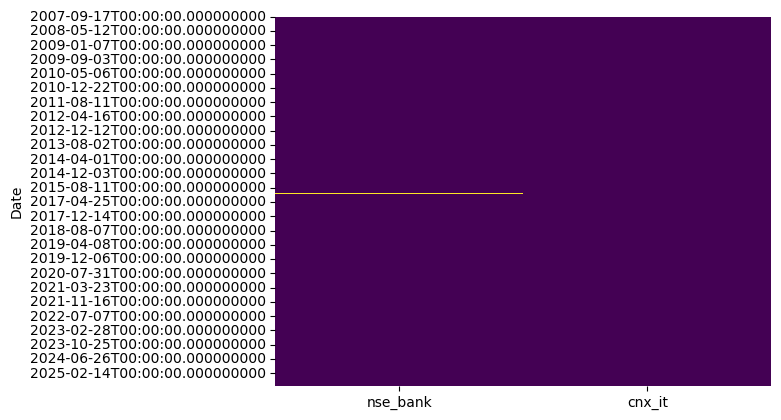

In [42]:
tdf = pd.DataFrame()
tdf["temp"]= daily_dispersion
sns.heatmap(sector_df.isnull(), cbar=False, cmap='viridis')

In [15]:
df["trend_strength_200"] = (
    df["Close"] - df["Close"].rolling(200).mean()
) / df["Close"].rolling(200).std()

In [37]:
market_vol = np.log(df["Close"] / df["Close"].shift(1)).rolling(20).std()

df["sector_dispersion_ratio_20"] = (
    daily_dispersion.rolling(20).mean() / market_vol
)
print("Null value count", df["sector_dispersion_ratio_20"].isnull().sum(), daily_dispersion.isnull().sum(), market_vol.isnull().sum(), daily_dispersion.rolling(20).mean().isnull().sum())

Null value count 437 33 20 164


In [28]:
df["sector_dispersion_ratio_20"] 

Date
2007-09-17         NaN
2007-09-18         NaN
2007-09-19         NaN
2007-09-20         NaN
2007-09-21         NaN
                ...   
2025-09-15    1.417814
2025-09-16    1.422829
2025-09-17    1.421272
2025-09-18    1.239295
2025-09-19         NaN
Name: sector_dispersion_ratio_20, Length: 4418, dtype: float64

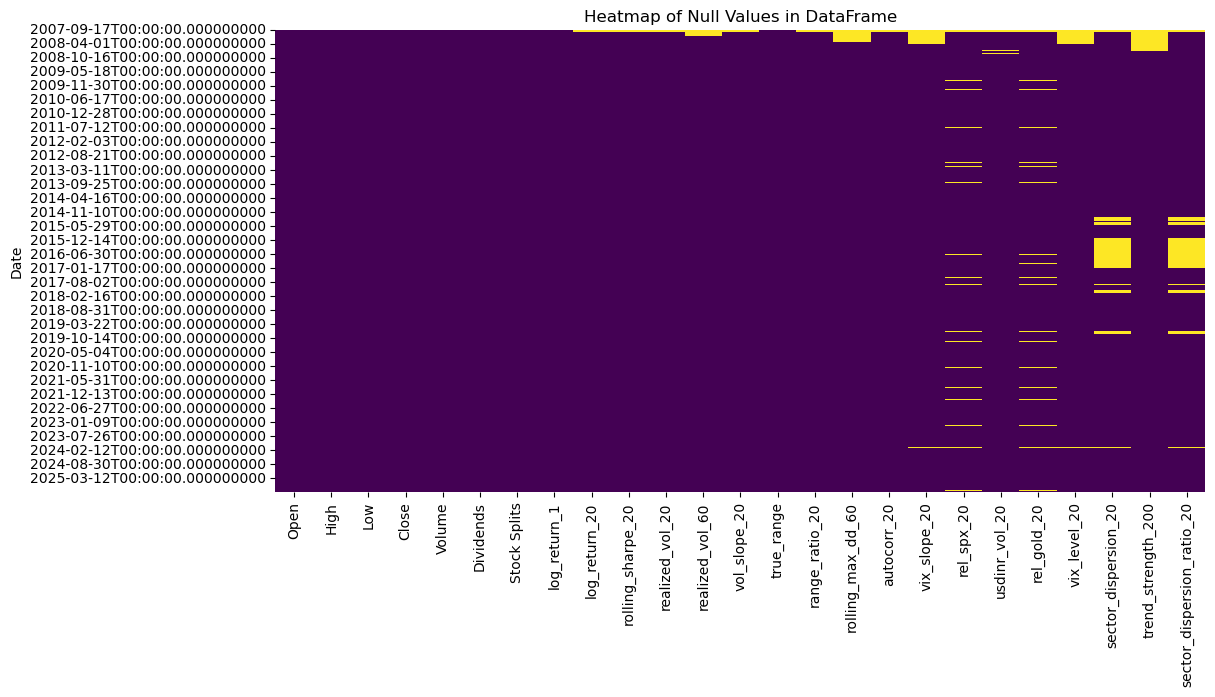

In [29]:
# plot a heatmap of null values in df
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Null Values in DataFrame')
plt.show()

In [25]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits',
       'log_return_1', 'log_return_20', 'rolling_sharpe_20', 'realized_vol_20',
       'realized_vol_60', 'vol_slope_20', 'true_range', 'range_ratio_20',
       'rolling_max_dd_60', 'autocorr_20', 'vix_slope_20', 'rel_spx_20',
       'usdinr_vol_20', 'rel_gold_20', 'vix_level_20', 'sector_dispersion_20',
       'trend_strength_200', 'sector_dispersion_ratio_20'],
      dtype='object')

<Axes: xlabel='sector_dispersion_ratio_20', ylabel='Count'>

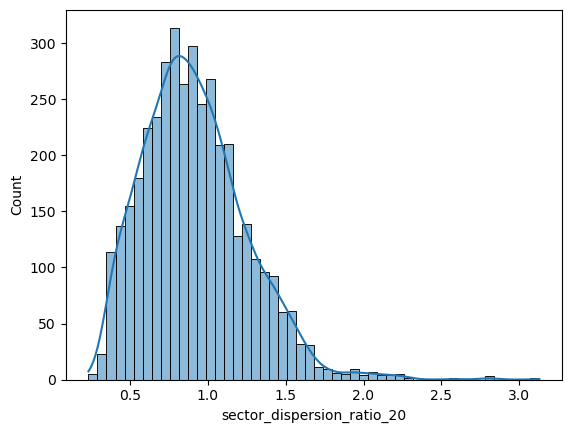

In [30]:
sns.histplot(df["sector_dispersion_ratio_20"], bins=50, kde=True)

In [27]:
df.isnull().sum()

Open                            0
High                            0
Low                             0
Close                           0
Volume                          0
Dividends                       0
Stock Splits                    0
log_return_1                    1
log_return_20                  20
rolling_sharpe_20              20
realized_vol_20                20
realized_vol_60                60
vol_slope_20                   21
true_range                      1
range_ratio_20                 19
rolling_max_dd_60             118
autocorr_20                    20
vix_slope_20                  155
rel_spx_20                    142
usdinr_vol_20                  48
rel_gold_20                   143
vix_level_20                  154
sector_dispersion_20          437
trend_strength_200            199
sector_dispersion_ratio_20    437
dtype: int64

In [25]:
FEATURES = [
    'Close',
    
    'log_return_20', 
    'rolling_sharpe_20', 
    'rolling_max_dd_60',

    'realized_vol_20',
    'realized_vol_60', 
    'vol_slope_20', 

    'range_ratio_20',
    'autocorr_20',

    'rel_spx_20',
    'usdinr_vol_20', 
    'rel_gold_20', 
    'vix_level_20',

    'vix_slope_20', 
    'trend_strength_200',

    'sector_dispersion_ratio_20', 
    'sector_dispersion_20'
]

In [26]:
df_feat = df[FEATURES].dropna()

In [27]:
df_feat

,Close,log_return_20,rolling_sharpe_20,rolling_max_dd_60,realized_vol_20,realized_vol_60,vol_slope_20,range_ratio_20,autocorr_20,rel_spx_20,usdinr_vol_20,rel_gold_20,vix_level_20,vix_slope_20,trend_strength_200,sector_dispersion_ratio_20,sector_dispersion_20
Date,,,,,,,,,,,,,,,,,
2008-07-07,4030.000000,-0.110522,-0.224338,-0.254667,0.110180,0.141355,-0.003398,0.033724,-0.219374,-0.027527,0.002786,-0.145529,32.1885,0.2430,-2.110362,0.448846,0.011056
2008-07-08,3988.550049,-0.109431,-0.222237,-0.254667,0.110072,0.141512,-0.000108,0.033671,-0.215630,-0.042579,0.002831,-0.139380,32.4790,0.2905,-2.162983,0.498549,0.012274
2008-07-09,4157.100098,-0.084490,-0.160266,-0.254667,0.116441,0.147411,0.006369,0.035011,-0.235864,0.002960,0.003098,-0.150691,32.7105,0.2315,-1.850902,0.452034,0.011915
2008-07-10,4162.200195,-0.086740,-0.164720,-0.254667,0.116395,0.147115,-0.000045,0.034202,-0.194999,-0.023294,0.002778,-0.153996,32.8575,0.1470,-1.824591,0.454354,0.011963
2008-07-11,4049.000000,-0.109400,-0.203813,-0.254667,0.119516,0.148183,0.003121,0.035888,-0.202349,-0.031528,0.003048,-0.208239,32.9730,0.1155,-1.999600,0.500986,0.013446
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-12,25114.000000,0.019893,0.187062,-0.049712,0.023600,0.042602,-0.000214,0.006597,0.116938,0.002157,0.002392,-0.070137,11.3530,-0.1010,1.094953,1.386790,0.007374
2025-09-15,25069.199219,0.017622,0.164607,-0.049712,0.023662,0.042633,0.000062,0.006620,0.116114,-0.007711,0.002327,-0.081116,11.2550,-0.0980,1.037760,1.417814,0.007589
2025-09-16,25239.099609,0.014453,0.141348,-0.049712,0.022518,0.041226,-0.001145,0.006659,0.016878,-0.009692,0.002284,-0.087393,11.1515,-0.1035,1.215327,1.422829,0.007274


In [28]:
temp_copy = df_feat.copy()
df_feat = df_feat.drop("Close", axis=1)

In [29]:
df_feat

,log_return_20,rolling_sharpe_20,rolling_max_dd_60,realized_vol_20,realized_vol_60,vol_slope_20,range_ratio_20,autocorr_20,rel_spx_20,usdinr_vol_20,rel_gold_20,vix_level_20,vix_slope_20,trend_strength_200,sector_dispersion_ratio_20,sector_dispersion_20
Date,,,,,,,,,,,,,,,,
2008-07-07,-0.110522,-0.224338,-0.254667,0.110180,0.141355,-0.003398,0.033724,-0.219374,-0.027527,0.002786,-0.145529,32.1885,0.2430,-2.110362,0.448846,0.011056
2008-07-08,-0.109431,-0.222237,-0.254667,0.110072,0.141512,-0.000108,0.033671,-0.215630,-0.042579,0.002831,-0.139380,32.4790,0.2905,-2.162983,0.498549,0.012274
2008-07-09,-0.084490,-0.160266,-0.254667,0.116441,0.147411,0.006369,0.035011,-0.235864,0.002960,0.003098,-0.150691,32.7105,0.2315,-1.850902,0.452034,0.011915
2008-07-10,-0.086740,-0.164720,-0.254667,0.116395,0.147115,-0.000045,0.034202,-0.194999,-0.023294,0.002778,-0.153996,32.8575,0.1470,-1.824591,0.454354,0.011963
2008-07-11,-0.109400,-0.203813,-0.254667,0.119516,0.148183,0.003121,0.035888,-0.202349,-0.031528,0.003048,-0.208239,32.9730,0.1155,-1.999600,0.500986,0.013446
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-12,0.019893,0.187062,-0.049712,0.023600,0.042602,-0.000214,0.006597,0.116938,0.002157,0.002392,-0.070137,11.3530,-0.1010,1.094953,1.386790,0.007374
2025-09-15,0.017622,0.164607,-0.049712,0.023662,0.042633,0.000062,0.006620,0.116114,-0.007711,0.002327,-0.081116,11.2550,-0.0980,1.037760,1.417814,0.007589
2025-09-16,0.014453,0.141348,-0.049712,0.022518,0.041226,-0.001145,0.006659,0.016878,-0.009692,0.002284,-0.087393,11.1515,-0.1035,1.215327,1.422829,0.007274


In [30]:
mean = df_feat.mean()
std = df_feat.std()

df_feat = (df_feat - mean) / (std + 1e-8)

In [31]:
df_feat

,log_return_20,rolling_sharpe_20,rolling_max_dd_60,realized_vol_20,realized_vol_60,vol_slope_20,range_ratio_20,autocorr_20,rel_spx_20,usdinr_vol_20,rel_gold_20,vix_level_20,vix_slope_20,trend_strength_200,sector_dispersion_ratio_20,sector_dispersion_20
Date,,,,,,,,,,,,,,,,
2008-07-07,-1.979133,-1.233993,-1.790170,1.966213,1.088903,-0.832409,2.285305,-1.110913,-0.630254,-0.560954,-2.102724,1.329296,0.784362,-2.212219,-1.425551,0.752250
2008-07-08,-1.961051,-1.225482,-1.790170,1.962786,1.092023,-0.026427,2.279140,-1.092259,-0.957006,-0.545195,-2.014768,1.361443,0.934274,-2.254020,-1.277139,1.136946
2008-07-09,-1.547604,-0.974456,-1.790170,2.165194,1.209489,1.560028,2.433614,-1.193078,0.031579,-0.450395,-2.176565,1.387060,0.748067,-2.006110,-1.416032,1.023520
2008-07-10,-1.584896,-0.992495,-1.790170,2.163750,1.203590,-0.011146,2.340387,-0.989460,-0.538346,-0.563817,-2.223838,1.403327,0.481381,-1.985209,-1.409105,1.038556
2008-07-11,-1.960536,-1.150854,-1.790170,2.262930,1.224857,0.764398,2.534711,-1.026087,-0.717093,-0.468354,-2.999728,1.416108,0.381965,-2.124233,-1.269861,1.506830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-12,0.182761,0.432479,0.656711,-0.785516,-0.877555,-0.052374,-0.841782,0.564802,0.014138,-0.700379,-1.024336,-0.976323,-0.301320,0.334005,1.375161,-0.410826
2025-09-15,0.145118,0.341520,0.656711,-0.783531,-0.876945,0.015284,-0.839119,0.560695,-0.200074,-0.723288,-1.181373,-0.987168,-0.291852,0.288573,1.467799,-0.342798
2025-09-16,0.092581,0.247303,0.656711,-0.819908,-0.904957,-0.280392,-0.834702,0.066239,-0.243083,-0.738806,-1.271157,-0.998621,-0.309210,0.429627,1.482773,-0.442287


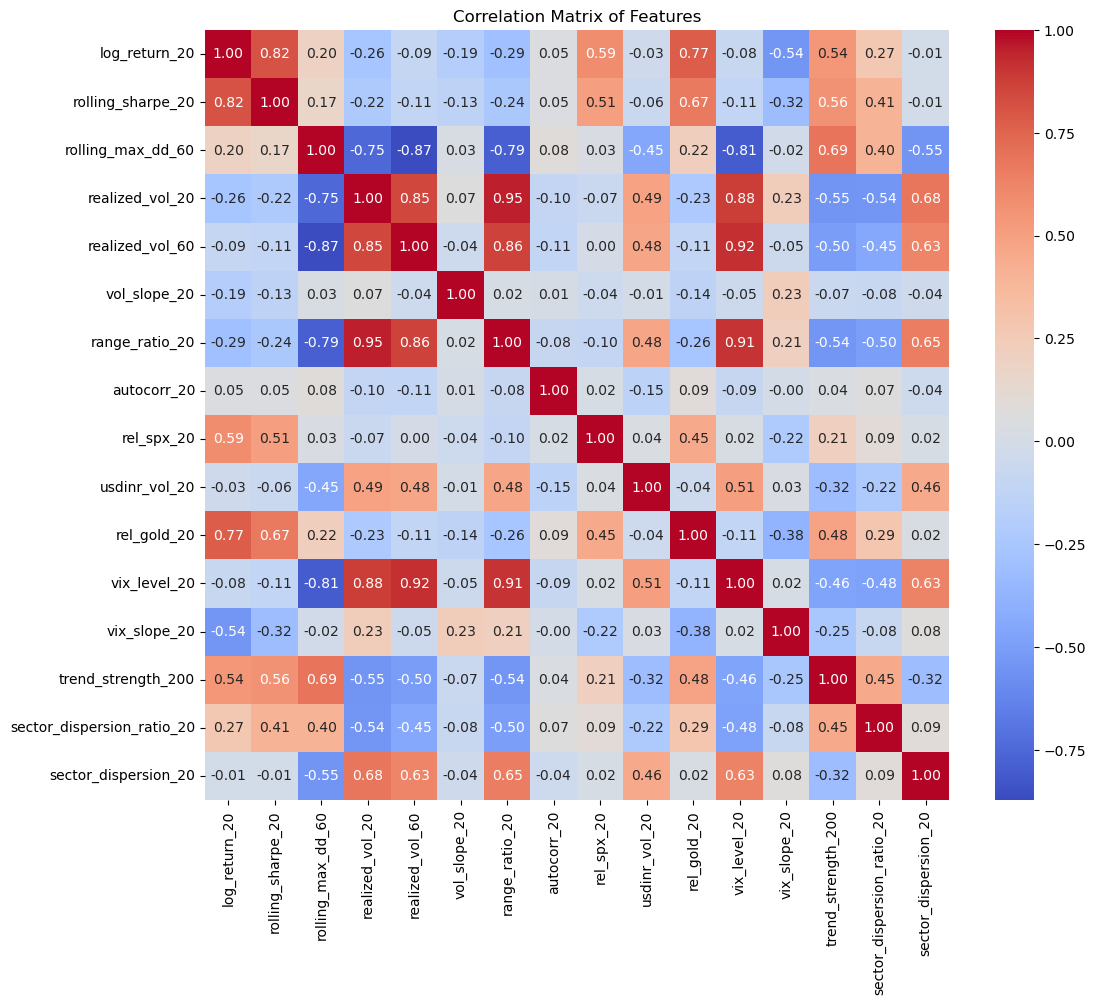

In [32]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_feat.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Features")
plt.show()

In [33]:
df_feat.corr().to_clipboard()

In [34]:
df_feat.describe().T

,count,mean,std,min,25%,50%,75%,max
log_return_20,3679.0,-1.738213e-17,1.000000,-8.230511,-0.440800,0.061299,0.534287,4.594424
rolling_sharpe_20,3679.0,2.317617e-17,1.000000,-2.824827,-0.706567,-0.033981,0.677665,2.934252
rolling_max_dd_60,3679.0,0.000000e+00,1.000000,-4.166152,-0.279286,0.173090,0.628433,1.075716
realized_vol_20,3679.0,1.390570e-16,1.000000,-1.090709,-0.575785,-0.259652,0.165594,6.513861
realized_vol_60,3679.0,-9.270468e-17,1.000000,-0.975145,-0.581632,-0.255454,0.147678,4.417014
vol_slope_20,3679.0,0.000000e+00,0.999998,-24.136355,-0.189202,-0.000021,0.196026,21.751194
range_ratio_20,3679.0,1.545078e-16,0.999999,-0.962818,-0.545361,-0.265041,0.151918,6.871597
autocorr_20,3679.0,3.862695e-17,1.000000,-3.282591,-0.660764,0.012850,0.652696,2.896156
rel_spx_20,3679.0,0.000000e+00,1.000000,-5.599840,-0.593271,-0.003328,0.585392,4.687852
usdinr_vol_20,3679.0,-3.090156e-17,0.999996,-1.392267,-0.606661,-0.211055,0.352467,8.001792


In [18]:
NEW_FEATURES = [
    'rolling_sharpe_20', 
    'rolling_max_dd_60',

    'realized_vol_20',
    'vol_slope_20', 

    'autocorr_20',

    'rel_spx_20',
    'usdinr_vol_20', 
    'rel_gold_20', 
    'vix_level_20',

    'vix_slope_20', 
    'trend_strength_200',

    'sector_dispersion_ratio_20', 
]
df_feat = df[NEW_FEATURES].dropna()

In [19]:
mean = df_feat.mean()
std = df_feat.std()

df_feat = (df_feat - mean) / (std + 1e-8)

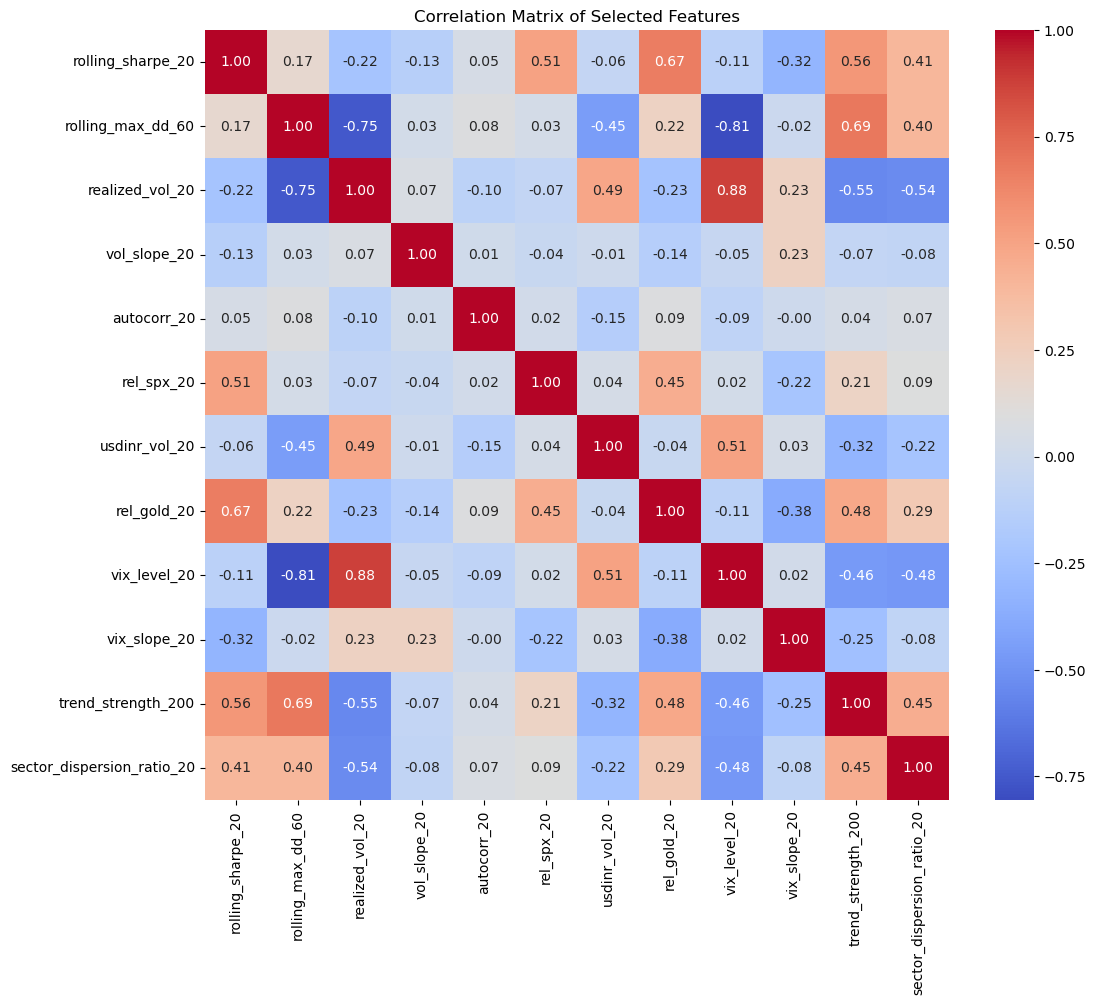

In [20]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_feat.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Selected Features")
plt.show()

In [21]:
df_feat["Close"] = temp_copy["Close"]

NameError: name 'temp_copy' is not defined

In [22]:
df_feat.isnull().sum()

rolling_sharpe_20             0
rolling_max_dd_60             0
realized_vol_20               0
vol_slope_20                  0
autocorr_20                   0
rel_spx_20                    0
usdinr_vol_20                 0
rel_gold_20                   0
vix_level_20                  0
vix_slope_20                  0
trend_strength_200            0
sector_dispersion_ratio_20    0
dtype: int64

In [40]:
import pickle

In [41]:
with open('../../data/nifty_ts2vec.pkl', 'wb') as file:
    pickle.dump(df_feat, file)

In [42]:
# read the data back
with open('../../data/nifty_ts2vec.pkl', 'rb') as file:
    df_feat = pickle.load(file)

df_feat

,rolling_sharpe_20,rolling_max_dd_60,realized_vol_20,vol_slope_20,autocorr_20,rel_spx_20,usdinr_vol_20,rel_gold_20,vix_level_20,vix_slope_20,trend_strength_200,sector_dispersion_ratio_20,Close
Date,,,,,,,,,,,,,
2008-07-07,-1.233993,-1.790170,1.966213,-0.832409,-1.110913,-0.630254,-0.560954,-2.102724,1.329296,0.784362,-2.212219,-1.425551,4030.000000
2008-07-08,-1.225482,-1.790170,1.962786,-0.026427,-1.092259,-0.957006,-0.545195,-2.014768,1.361443,0.934274,-2.254020,-1.277139,3988.550049
2008-07-09,-0.974456,-1.790170,2.165194,1.560028,-1.193078,0.031579,-0.450395,-2.176565,1.387060,0.748067,-2.006110,-1.416032,4157.100098
2008-07-10,-0.992495,-1.790170,2.163750,-0.011146,-0.989460,-0.538346,-0.563817,-2.223838,1.403327,0.481381,-1.985209,-1.409105,4162.200195
2008-07-11,-1.150854,-1.790170,2.262930,0.764398,-1.026087,-0.717093,-0.468354,-2.999728,1.416108,0.381965,-2.124233,-1.269861,4049.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-12,0.432479,0.656711,-0.785516,-0.052374,0.564802,0.014138,-0.700379,-1.024336,-0.976323,-0.301320,0.334005,1.375161,25114.000000
2025-09-15,0.341520,0.656711,-0.783531,0.015284,0.560695,-0.200074,-0.723288,-1.181373,-0.987168,-0.291852,0.288573,1.467799,25069.199219
2025-09-16,0.247303,0.656711,-0.819908,-0.280392,0.066239,-0.243083,-0.738806,-1.271157,-0.998621,-0.309210,0.429627,1.482773,25239.099609


In [24]:
df_feat

,rolling_sharpe_20,rolling_max_dd_60,realized_vol_20,vol_slope_20,autocorr_20,rel_spx_20,usdinr_vol_20,rel_gold_20,vix_level_20,vix_slope_20,trend_strength_200,sector_dispersion_ratio_20
Date,,,,,,,,,,,,
2008-07-07,-1.233993,-1.790170,1.966213,-0.832409,-1.110913,-0.630254,-0.560954,-2.102724,1.329296,0.784362,-2.212219,-1.425551
2008-07-08,-1.225482,-1.790170,1.962786,-0.026427,-1.092259,-0.957006,-0.545195,-2.014768,1.361443,0.934274,-2.254020,-1.277139
2008-07-09,-0.974456,-1.790170,2.165194,1.560028,-1.193078,0.031579,-0.450395,-2.176565,1.387060,0.748067,-2.006110,-1.416032
2008-07-10,-0.992495,-1.790170,2.163750,-0.011146,-0.989460,-0.538346,-0.563817,-2.223838,1.403327,0.481381,-1.985209,-1.409105
2008-07-11,-1.150854,-1.790170,2.262930,0.764398,-1.026087,-0.717093,-0.468354,-2.999728,1.416108,0.381965,-2.124233,-1.269861
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-12,0.432479,0.656711,-0.785516,-0.052374,0.564802,0.014138,-0.700379,-1.024336,-0.976323,-0.301320,0.334005,1.375161
2025-09-15,0.341520,0.656711,-0.783531,0.015284,0.560695,-0.200074,-0.723288,-1.181373,-0.987168,-0.291852,0.288573,1.467799
2025-09-16,0.247303,0.656711,-0.819908,-0.280392,0.066239,-0.243083,-0.738806,-1.271157,-0.998621,-0.309210,0.429627,1.482773
